In [2]:
import numpy as np
import scipy.sparse as sp
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [3]:
# 1. Load Data Fitur dan Label
feature_dir = 'extracted_features'

y = np.load(os.path.join(feature_dir, 'y_labels.npy'))
X_tfidf = sp.load_npz(os.path.join(feature_dir, 'X_tfidf.npz')).todense()
X_w2v = np.load(os.path.join(feature_dir, 'X_w2v.npy'))
X_glove = np.load(os.path.join(feature_dir, 'X_glove.npy'))
X_ft = np.load(os.path.join(feature_dir, 'X_ft.npy'))

features_dict = {
    'TF-IDF': np.asarray(X_tfidf),
    'Word2Vec': X_w2v,
    'GloVe': X_glove,
    'FastText': X_ft
}

# 2. Bentuk ulang data_splits khusus untuk data Test
data_splits = {}
for name, feature_matrix in features_dict.items():
    # Membagi data persis seperti di file training
    _, X_test, _, y_test = train_test_split(feature_matrix, y, test_size=0.2, random_state=42)
    data_splits[name] = {
        'X_test': X_test,
        'y_test': y_test
    }

print("Data uji (X_test dan y_test) berhasil disiapkan kembali!")

Data uji (X_test dan y_test) berhasil disiapkan kembali!


In [4]:
# Menetapkan nama model dan fitur terbaik berdasarkan hasil training sebelumnya
best_model_name = 'XGBoost'
best_feature_name = 'TF-IDF'

# Load model terbaik dari folder Model
model_path = '../Model/best_fake_news_model.joblib'
best_xgb = joblib.load(model_path)

print(f"Model {best_model_name} dengan fitur {best_feature_name} berhasil dimuat!")

Model XGBoost dengan fitur TF-IDF berhasil dimuat!


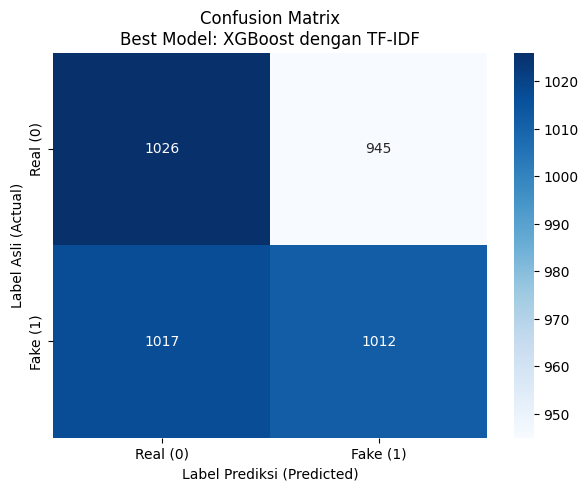

In [5]:
# Mengambil data test dari fitur model terbaik
X_test_best = data_splits[best_feature_name]['X_test']
y_test_best = data_splits[best_feature_name]['y_test']

# Melakukan prediksi menggunakan model terbaik
y_pred_best = best_xgb.predict(X_test_best)

# Membuat Confusion Matrix
cm = confusion_matrix(y_test_best, y_pred_best)

# Plotting Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real (0)', 'Fake (1)'], 
            yticklabels=['Real (0)', 'Fake (1)'])
plt.title(f'Confusion Matrix\nBest Model: {best_model_name} dengan {best_feature_name}')
plt.ylabel('Label Asli (Actual)')
plt.xlabel('Label Prediksi (Predicted)')
plt.show()

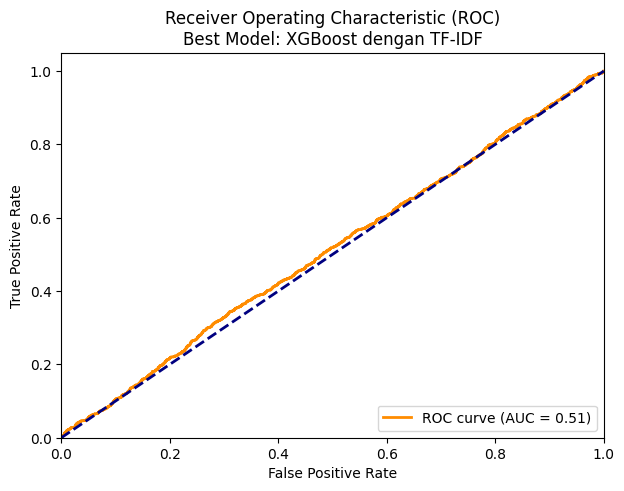

In [6]:
# Mengambil probabilitas prediksi untuk kelas positif (Fake / 1)
y_pred_proba = best_xgb.predict_proba(X_test_best)[:, 1]

# Menghitung metrik ROC
fpr, tpr, thresholds = roc_curve(y_test_best, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plotting ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC)\nBest Model: {best_model_name} dengan {best_feature_name}')
plt.legend(loc="lower right")
plt.show()